In [ ]:
# Importações necessárias para a modelagem e NLP

import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report


In [ ]:
import kagglehub

# Download do dataset
path = kagglehub.dataset_download("vishakhdapat/imdb-movie-reviews")

print("Path to dataset files:", path)

# O arquivo principal é 'IMDB Dataset.csv'
csv_file = path + "/IMDB Dataset.csv"

# Carregar o CSV
df = pd.read_csv(csv_file)


Using Colab cache for faster access to the 'imdb-movie-reviews' dataset.
Path to dataset files: /kaggle/input/imdb-movie-reviews


In [ ]:
# Configuração do pré-processamento (Lematização)
nltk.download('stopwords')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text_with_lemmatization(text):
    #Realiza a limpeza e padronização do texto.
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z]", " ", text)
    text = text.lower()
    tokens = text.split()

    # Remove palavras comuns sem valor semântico (stopwords)
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (redução à forma base da palavra, ex: amar = amei, amava, amavel, etc...)
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(tokens)

# Aplica o pré-processamento e cria a coluna limpa
print("Aplicando lematização e limpeza aos reviews...")
df['clean_review'] = df['review'].apply(preprocess_text_with_lemmatization)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


Aplicando lematização e limpeza aos reviews...


In [ ]:
# Vetorização TF-IDF e mapeamento do target

# Transforma os textos limpos em vetores numéricos.
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X = tfidf_vectorizer.fit_transform(df['clean_review'])

# Mapeamento do target como: 'positive' (1) e 'negative' (0).
y = df['sentiment'].map({'positive': 1, 'negative': 0})


In [ ]:
# Divisão estratificada (70% Treino, 15% Validação, 15% Testet)

# Separação do Teste (15%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Separação de Treino (70%) e Validação (15%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42, stratify=y_temp
)

print("\n--- Divisão de Dados Concluída ---")
print(f"Treino (70%): {X_train.shape}")
print(f"Validação (15%): {X_val.shape}")
print(f"Teste (15%): {X_test.shape}")


--- Divisão de Dados Concluída ---
Treino (70%): (34998, 5000)
Validação (15%): (7502, 5000)
Teste (15%): (7500, 5000)



--- Iniciando Treinamento da Regressão Logística ---

--- Resultados Finais do Modelo (Etapa 3) ---
Acurácia: 0.8876
F1-Score: 0.8892

Relatório de Classificação (Detalhado):
               precision    recall  f1-score   support

           0       0.90      0.87      0.89      3750
           1       0.88      0.90      0.89      3750

    accuracy                           0.89      7500
   macro avg       0.89      0.89      0.89      7500
weighted avg       0.89      0.89      0.89      7500



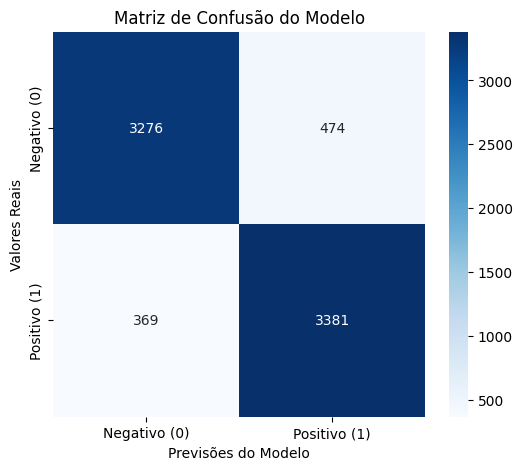

In [ ]:
# Treinamento e Medidas de Acurácia (Modelo Baseline)

print("\n--- Iniciando Treinamento da Regressão Logística ---")

# Modelo Baseline
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Geração de previsões na Base de Teste
y_pred = log_model.predict(X_test)

# Cálculo e apresentação das métricas
print("\n--- Resultados Finais do Modelo (Etapa 3) ---")
print(f"Acurácia: {accuracy_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print("\nRelatório de Classificação (Detalhado):\n", classification_report(y_test, y_pred))

# Visualizaçao da Matriz de Confusão
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negativo (0)', 'Positivo (1)'],
            yticklabels=['Negativo (0)', 'Positivo (1)'])
plt.ylabel('Valores Reais')
plt.xlabel('Previsões do Modelo')
plt.title('Matriz de Confusão do Modelo')
plt.show()

In [ ]:
# Análise da polaridade (Pesos do Modelo)

# Obtém os nomes das palavras (features)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Obtém os coeficientes (pesos) do modelo
coefs = log_model.coef_[0]

# Cria um DataFrame para correlacionar palavra e peso
coef_df = pd.DataFrame({
    'word': feature_names,
    'coefficient': coefs
})

# Palavras Mais Positivas (Ordena por coeficientes mais altos)
top_pos_words = coef_df.sort_values(by='coefficient', ascending=False).head(20)

# Palavras Mais Negativas (Ordena por coeficientes mais baixos)
top_neg_words = coef_df.sort_values(by='coefficient', ascending=True).head(20)


print("\n--- 20 PALAVRAS MAIS POLARIZADAS PARA SENTIMENTO POSITIVO ---")
print(top_pos_words)

print("\n--- 20 PALAVRAS MAIS POLARIZADAS PARA SENTIMENTO NEGATIVO ---")
print(top_neg_words)


--- 20 PALAVRAS MAIS POLARIZADAS PARA SENTIMENTO POSITIVO ---
            word  coefficient
1935       great     6.828782
1527   excellent     6.397062
3208     perfect     5.201169
405         best     4.820670
149      amazing     4.666152
4934   wonderful     4.631564
2082   hilarious     4.358682
1643    favorite     4.337865
1818         fun     4.078264
2648       loved     4.055532
1140  definitely     3.938438
1456     enjoyed     3.821394
525    brilliant     3.812299
4336      superb     3.800439
4868        well     3.793392
1455   enjoyable     3.723706
4526       today     3.709499
2081      highly     3.701562
1822    funniest     3.478184
2647        love     3.472302

--- 20 PALAVRAS MAIS POLARIZADAS PARA SENTIMENTO NEGATIVO ---
                word  coefficient
4955           worst    -9.999066
4837           waste    -7.610678
310            awful    -7.532548
319              bad    -7.313406
483           boring    -6.046660
3315            poor    -5.531513
4452  

/tmp/ipython-input-1418208425.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


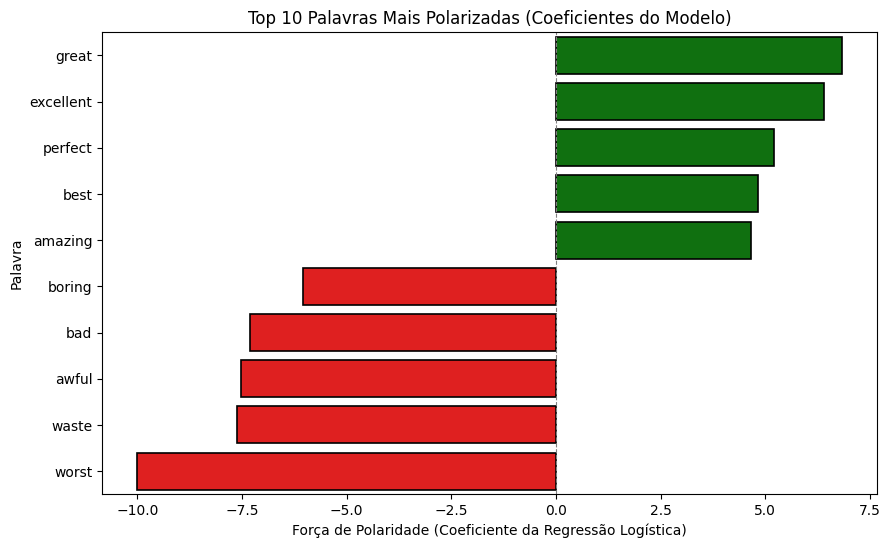

In [ ]:
# Visualização de Polaridade (TOP 5 positivas e TOP 5 negativas)

# Concatena as 5 palavras mais positivas e as 5 mais negativas
top_5_pos = coef_df.sort_values(by='coefficient', ascending=False).head(5)
top_5_neg = coef_df.sort_values(by='coefficient', ascending=False).tail(5)

final_plot_df = pd.concat([top_5_pos, top_5_neg])

# Formatação do gráfico
final_plot_df['sentiment_color'] = final_plot_df['coefficient'].apply(
    lambda x: 'green' if x > 0 else 'red'
)

# Cria a visualização
plt.figure(figsize=(10, 6))
sns.barplot(
    x='coefficient',
    y='word',
    data=final_plot_df,
    palette=final_plot_df['sentiment_color'].tolist(),
    edgecolor='black',
    linewidth=1.2
)
plt.title('Top 10 Palavras Mais Polarizadas (Coeficientes do Modelo)')
plt.xlabel('Força de Polaridade (Coeficiente da Regressão Logística)')
plt.ylabel('Palavra')
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.show()

In [ ]:
# Teste de Inferência: Previsão em Novas Frases

# Teste manual com novas frases
new_reviews = [
    "This movie was an absolute masterpiece; every scene was brilliant and the acting superb.",
    "What a complete waste of time. The plot was boring and the ending was awful.",
    "It's okay, nothing special, but I enjoyed the final scene.",
    "I was so disappointed with the terrible script and the worst director I have ever seen.",
    "I didn't like this movie.",
]

print("\n--- INICIANDO TESTE DE INFERÊNCIA ---")

# Pré-processamento das novas frases
processed_reviews = [preprocess_text_with_lemmatization(review) for review in new_reviews]

# Vetorização (usando o objeto 'tfidf_vectorizer' que fi treinado)
X_new = tfidf_vectorizer.transform(processed_reviews)

# Previsão
predictions = log_model.predict(X_new)

# Apresentação dos resultados
print("\n| Original Review | Previsão do Modelo |")
print("| :--- | :--- |")

for review, pred in zip(new_reviews, predictions):
    # Converte 1 para 'Positive' e 0 para 'Negative'
    sentiment = 'POSITIVO' if pred == 1 else 'NEGATIVO'
    print(f"| {review[:60]}... | {sentiment} |")


--- INICIANDO TESTE DE INFERÊNCIA ---

| Original Review | Previsão do Modelo |
| :--- | :--- |
| This movie was an absolute masterpiece; every scene was bril... | POSITIVO |
| What a complete waste of time. The plot was boring and the e... | NEGATIVO |
| It's okay, nothing special, but I enjoyed the final scene.... | NEGATIVO |
| I was so disappointed with the terrible script and the worst... | NEGATIVO |
| I didn't like this movie.... | NEGATIVO |
